# **Prédiction de la Durée d'Hospitalisation**
## Comparaison de Modèles de Machine Learning

**Objectif** : Estimer la durée d'hospitalisation (`lengthofstay`) d'un patient en fonction de ses antécédents médicaux et mesures biologiques.

**Approche pédagogique** : Tester plusieurs modèles pour identifier le plus performant.

---
## 1. Imports et Configuration

In [1]:
!pip install xgboost seaborn

# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Modèles
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# XGBoost (installer si nécessaire : !pip install xgboost)
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    print("XGBoost non installé. Exécuter: !pip install xgboost")
    XGBOOST_AVAILABLE = False

# Métriques
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuration d'affichage
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Imports réussis")


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
✅ Imports réussis


---
## 2. Chargement et Exploration des Données

In [2]:
# Charger le dataset
# Adapter le chemin selon votre environnement
# df = pd.read_csv('/content/drive/MyDrive/cmv-ia/LengthOfStay.csv')  # Google Colab
df = pd.read_csv('LengthOfStay.csv')  # Local

print(f"Dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
df.info()

Dataset : 100,000 lignes × 28 colonnes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   vdate                       100000 non-null  object 
 2   rcount                      100000 non-null  object 
 3   gender                      100000 non-null  object 
 4   dialysisrenalendstage       100000 non-null  int64  
 5   asthma                      100000 non-null  int64  
 6   irondef                     100000 non-null  int64  
 7   pneum                       100000 non-null  int64  
 8   substancedependence         100000 non-null  int64  
 9   psychologicaldisordermajor  100000 non-null  int64  
 10  depress                     100000 non-null  int64  
 11  psychother                  100000 non-null  int64  
 12  fibrosisandother            100000

In [3]:
df.head()

,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.5,14.20,140.361132,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,0,0,0,0,0,9.0,4.10,136.731692,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,0,0,0,0,0,8.4,8.90,133.058514,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.9,9.40,138.994023,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,0,0,0,0,0,9.1,9.05,138.634836,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4


In [4]:
# Statistiques descriptives
df.describe()

,eid,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,lengthofstay
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000
mean,50000.500000,0.036420,0.035270,0.094940,0.039450,0.063060,0.239040,0.051660,0.049390,0.004790,0.049480,0.080000,11.975939,10.177455,137.891397,141.963384,14.097185,1.099350,29.805759,73.444720,6.493768,2.123310,4.00103
std,28867.657797,0.187334,0.184462,0.293134,0.194664,0.243072,0.426499,0.221341,0.216682,0.069044,0.216869,0.271295,2.031792,5.353131,2.999669,29.992996,12.952454,0.200262,2.003769,11.644555,0.568473,2.050641,2.36031
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.400000,0.100000,124.912632,-1.005927,1.000000,0.219770,21.992683,21.000000,0.200000,0.000000,1.00000
25%,25000.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.900000,7.700000,135.871062,121.682383,11.000000,0.964720,28.454235,66.000000,6.500000,1.000000,2.00000
50%,50000.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.900000,9.400000,137.887151,142.088545,12.000000,1.098764,29.807516,73.000000,6.500000,1.000000,4.00000
75%,75000.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.900000,11.500000,139.912885,162.180996,14.000000,1.234867,31.156885,81.000000,6.500000,3.000000,6.00000
max,100000.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,24.100000,245.900000,151.387283,271.444277,682.500000,2.035202,38.935293,130.000000,10.000000,10.000000,17.00000


In [5]:
# Vérifier les valeurs manquantes
missing = df.isnull().sum()
print("Valeurs manquantes par colonne :")
print(missing[missing > 0] if missing.sum() > 0 else "Aucune valeur manquante ✅")

Valeurs manquantes par colonne :
Aucune valeur manquante ✅


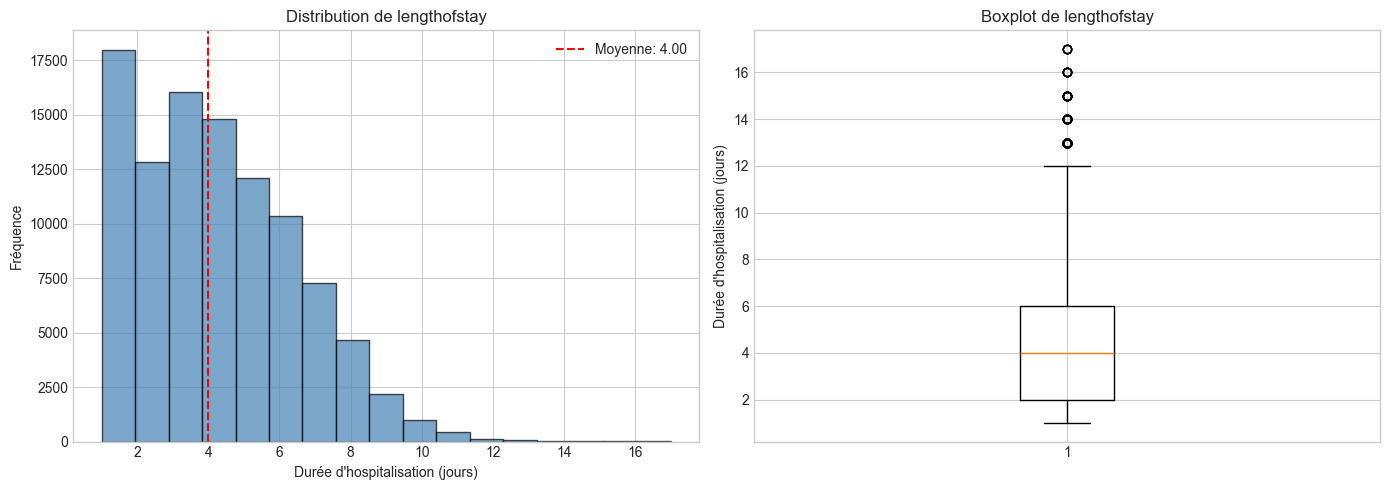


Statistiques de la variable cible :
  Moyenne : 4.00 jours
  Médiane : 4.00 jours
  Min-Max : 1 - 17 jours


In [6]:
# Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(df['lengthofstay'], bins=17, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Durée d\'hospitalisation (jours)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de lengthofstay')
axes[0].axvline(df['lengthofstay'].mean(), color='red', linestyle='--', label=f'Moyenne: {df["lengthofstay"].mean():.2f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['lengthofstay'], vert=True)
axes[1].set_ylabel('Durée d\'hospitalisation (jours)')
axes[1].set_title('Boxplot de lengthofstay')

plt.tight_layout()
plt.show()

print(f"\nStatistiques de la variable cible :")
print(f"  Moyenne : {df['lengthofstay'].mean():.2f} jours")
print(f"  Médiane : {df['lengthofstay'].median():.2f} jours")
print(f"  Min-Max : {df['lengthofstay'].min()} - {df['lengthofstay'].max()} jours")

---
## 3. Préparation des Données (Feature Engineering)

In [7]:
# Copie du dataframe pour le preprocessing
df_processed = df.copy()

# Colonnes à supprimer (identifiants, dates)
cols_to_drop = ['eid', 'vdate', 'discharged']
df_processed = df_processed.drop(columns=cols_to_drop)

print(f"Colonnes supprimées : {cols_to_drop}")
print(f"Colonnes restantes : {df_processed.shape[1]}")

Colonnes supprimées : ['eid', 'vdate', 'discharged']
Colonnes restantes : 25


In [8]:
# Identifier les colonnes catégorielles
cat_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
print(f"Colonnes catégorielles : {cat_cols}")

for col in cat_cols:
    print(f"\n{col} - Valeurs uniques : {df_processed[col].nunique()}")
    print(df_processed[col].value_counts())

Colonnes catégorielles : ['rcount', 'gender', 'facid']

rcount - Valeurs uniques : 6
rcount
0     55031
1     15007
2      9987
3      8047
4      6941
5+     4987
Name: count, dtype: int64

gender - Valeurs uniques : 2
gender
F    57643
M    42357
Name: count, dtype: int64

facid - Valeurs uniques : 5
facid
E    30755
A    30035
B    30012
C     4699
D     4499
Name: count, dtype: int64


In [9]:
# Encodage des variables catégorielles

# gender : F/M -> 0/1
df_processed['gender'] = df_processed['gender'].map({'F': 0, 'M': 1})

# rcount : 0, 1, 2, 3, 4, 5+ -> conversion numérique
df_processed['rcount'] = df_processed['rcount'].replace('5+', '5').astype(int)

# facid : One-Hot Encoding pour l'établissement
df_processed = pd.get_dummies(df_processed, columns=['facid'], prefix='facid', drop_first=True)

print("✅ Encodage terminé")
print(f"Shape après encodage : {df_processed.shape}")
df_processed.head()

✅ Encodage terminé
Shape après encodage : (100000, 28)


,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,lengthofstay,facid_B,facid_C,facid_D,facid_E
0,0,0,0,0,0,0,0,0,0,0,0,0,0,11.5,14.20,140.361132,192.476918,12.0,1.390722,30.432418,96,6.5,4,3,True,False,False,False
1,5,0,0,0,0,0,0,0,0,0,0,0,0,9.0,4.10,136.731692,94.078507,8.0,0.943164,28.460516,61,6.5,1,7,False,False,False,False
2,1,0,0,0,0,0,0,0,0,0,0,0,0,8.4,8.90,133.058514,130.530524,12.0,1.065750,28.843812,64,6.5,2,3,True,False,False,False
3,0,0,0,0,0,0,0,0,0,0,0,0,0,11.9,9.40,138.994023,163.377028,12.0,0.906862,27.959007,76,6.5,1,1,False,False,False,False
4,0,0,0,0,0,1,0,1,0,0,0,0,0,9.1,9.05,138.634836,94.886654,11.5,1.242854,30.258927,67,5.6,2,4,False,False,False,True


In [10]:
# Vérifier les types de données finaux
print("Types de données :")
print(df_processed.dtypes.value_counts())

Types de données :
int64      16
float64     8
bool        4
Name: count, dtype: int64


---
## 4. Analyse des Corrélations

In [11]:
# Matrice de corrélation avec la variable cible
correlations = df_processed.corr()['lengthofstay'].sort_values(ascending=False)
print("Corrélations avec lengthofstay :\n")
print(correlations)

Corrélations avec lengthofstay :

lengthofstay                  1.000000
rcount                        0.749514
facid_E                       0.326482
psychologicaldisordermajor    0.286724
hemo                          0.217696
irondef                       0.193838
psychother                    0.191695
malnutrition                  0.174397
dialysisrenalendstage         0.169695
bloodureanitro                0.148290
substancedependence           0.147886
pneum                         0.135461
depress                       0.121408
facid_C                       0.083670
asthma                        0.082005
facid_D                       0.076043
gender                        0.069575
fibrosisandother              0.062131
pulse                         0.006683
secondarydiagnosisnonicd9     0.006540
bmi                           0.000132
glucose                      -0.003447
sodium                       -0.003546
creatinine                   -0.004026
neutrophils                  -

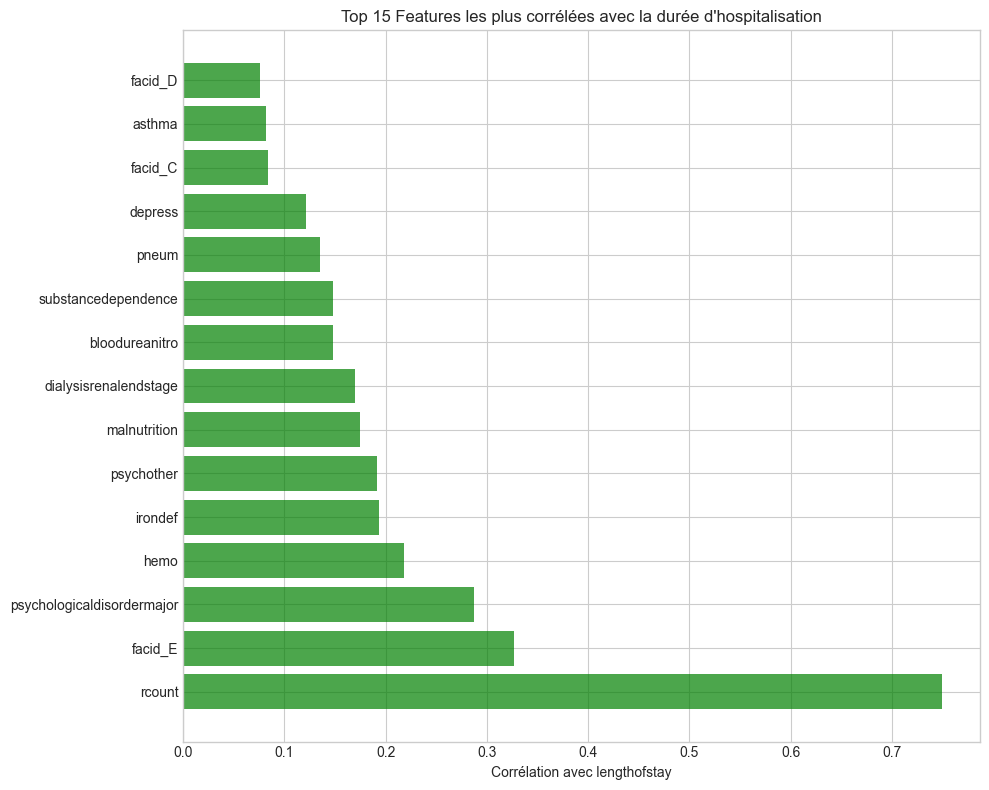

In [12]:
# Visualisation des corrélations (top features)
plt.figure(figsize=(10, 8))
top_corr = correlations.drop('lengthofstay').head(15)
colors = ['green' if x > 0 else 'red' for x in top_corr.values]
plt.barh(top_corr.index, top_corr.values, color=colors, alpha=0.7)
plt.xlabel('Corrélation avec lengthofstay')
plt.title('Top 15 Features les plus corrélées avec la durée d\'hospitalisation')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

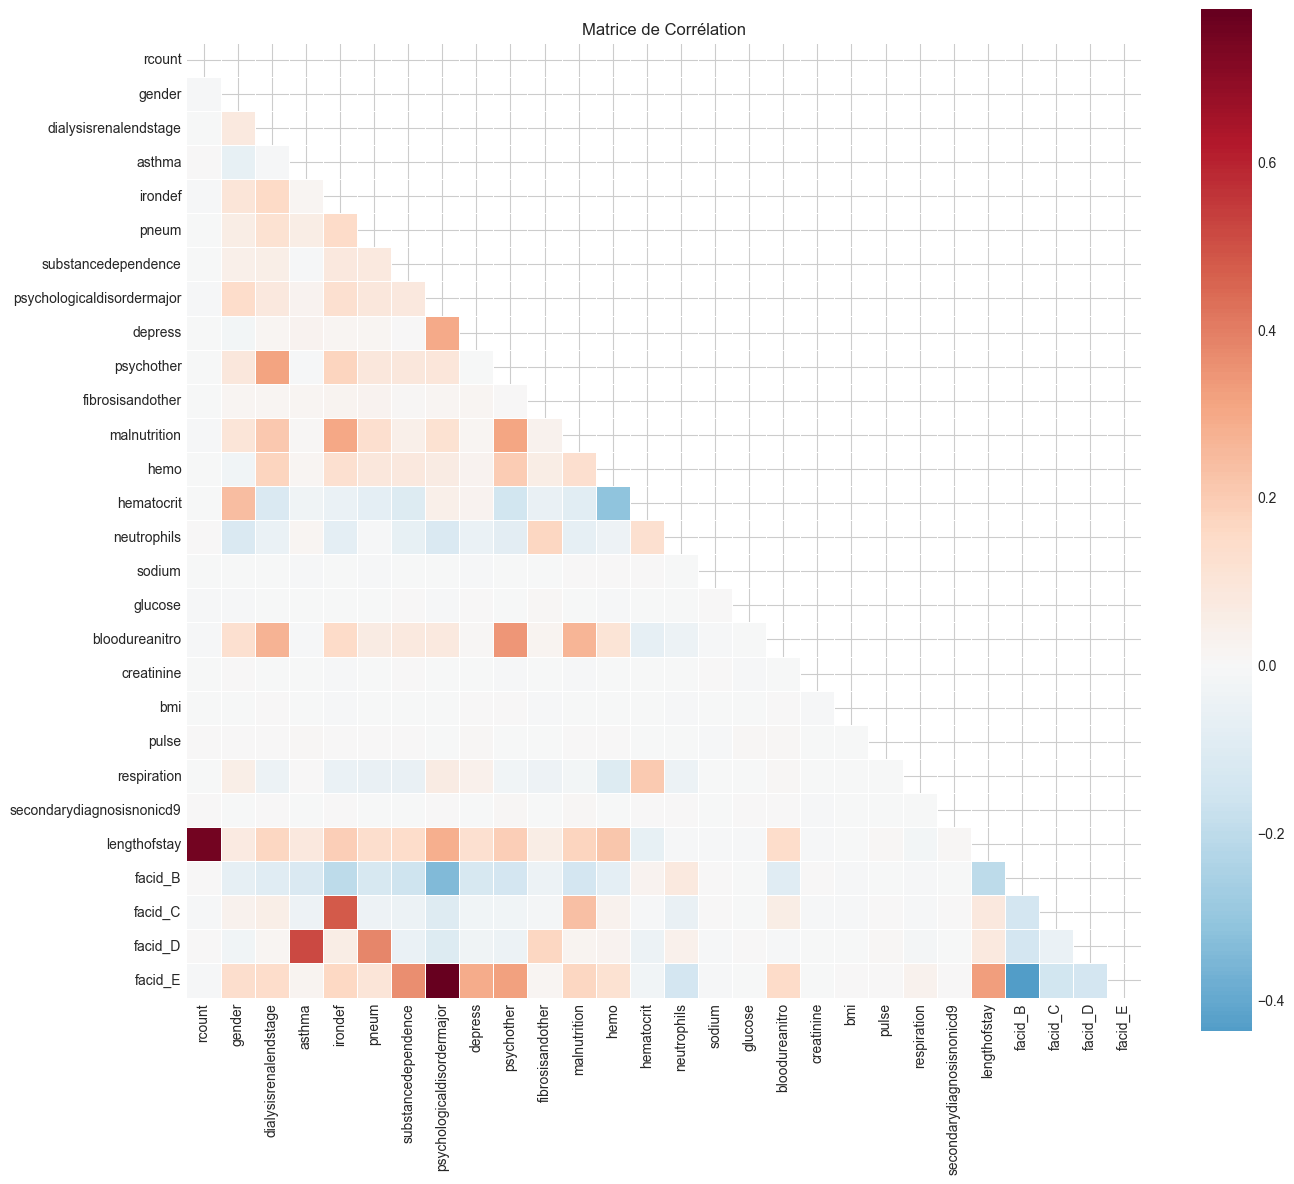

In [13]:
# Heatmap des corrélations (subset pour lisibilité)
plt.figure(figsize=(14, 12))
correlation_matrix = df_processed.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Matrice de Corrélation')
plt.tight_layout()
plt.show()

---
## 5. Préparation des Données pour la Modélisation

In [14]:
# Séparation Features / Target
X = df_processed.drop('lengthofstay', axis=1)
y = df_processed['lengthofstay']

print(f"Features (X) : {X.shape}")
print(f"Target (y)   : {y.shape}")
print(f"\nFeatures utilisées ({len(X.columns)}) :")
print(list(X.columns))

Features (X) : (100000, 27)
Target (y)   : (100000,)

Features utilisées (27) :
['rcount', 'gender', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9', 'facid_B', 'facid_C', 'facid_D', 'facid_E']


In [15]:
# Split Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train : {X_train.shape[0]:,} échantillons")
print(f"Test  : {X_test.shape[0]:,} échantillons")

Train : 80,000 échantillons
Test  : 20,000 échantillons


In [16]:
# Normalisation des features (important pour certains modèles)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Normalisation effectuée (StandardScaler)")

✅ Normalisation effectuée (StandardScaler)


---
## 6. Définition des Fonctions d'Évaluation

In [17]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Évalue un modèle et retourne les métriques.
    """
    # Prédictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Métriques Train
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    
    # Métriques Test
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    
    return {
        'Model': model_name,
        'Train_MAE': train_mae,
        'Train_RMSE': train_rmse,
        'Train_R2': train_r2,
        'Test_MAE': test_mae,
        'Test_RMSE': test_rmse,
        'Test_R2': test_r2
    }

def print_model_results(results):
    """
    Affiche les résultats d'un modèle.
    """
    print(f"\n{'='*60}")
    print(f"📊 {results['Model']}")
    print(f"{'='*60}")
    print(f"\n  TRAIN:")
    print(f"    MAE  : {results['Train_MAE']:.4f} jours")
    print(f"    RMSE : {results['Train_RMSE']:.4f} jours")
    print(f"    R²   : {results['Train_R2']:.4f}")
    print(f"\n  TEST:")
    print(f"    MAE  : {results['Test_MAE']:.4f} jours")
    print(f"    RMSE : {results['Test_RMSE']:.4f} jours")
    print(f"    R²   : {results['Test_R2']:.4f}")
    
    # Indicateur d'overfitting
    overfit_gap = results['Train_R2'] - results['Test_R2']
    if overfit_gap > 0.1:
        print(f"\n  ⚠️  Overfitting potentiel (gap R²: {overfit_gap:.4f})")
    else:
        print(f"\n  ✅ Bonne généralisation (gap R²: {overfit_gap:.4f})")

# Stockage des résultats
all_results = []

---
## 7. Entraînement et Comparaison des Modèles

### 7.1 Régression Linéaire (Baseline)

In [18]:
# 1. RÉGRESSION LINÉAIRE
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_results = evaluate_model(lr_model, X_train_scaled, X_test_scaled, y_train, y_test, "Régression Linéaire")
all_results.append(lr_results)
print_model_results(lr_results)


📊 Régression Linéaire

  TRAIN:
    MAE  : 0.8770 jours
    RMSE : 1.1556 jours
    R²   : 0.7612

  TEST:
    MAE  : 0.8664 jours
    RMSE : 1.1348 jours
    R²   : 0.7653

  ✅ Bonne généralisation (gap R²: -0.0041)


In [19]:
# Coefficients de la régression linéaire
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 10 coefficients les plus importants :")
print(coef_df.head(10).to_string(index=False))


Top 10 coefficients les plus importants :
                   Feature  Coefficient
                    rcount     1.777067
                   facid_E     0.364448
                      hemo     0.338821
psychologicaldisordermajor     0.335649
                   facid_C     0.236085
                   facid_D     0.193241
       substancedependence     0.143874
     dialysisrenalendstage     0.138618
                psychother     0.131449
               neutrophils     0.129266


### 7.2 Ridge Regression (Régularisation L2)

In [20]:
# 2. RIDGE REGRESSION
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)

ridge_results = evaluate_model(ridge_model, X_train_scaled, X_test_scaled, y_train, y_test, "Ridge Regression")
all_results.append(ridge_results)
print_model_results(ridge_results)


📊 Ridge Regression

  TRAIN:
    MAE  : 0.8770 jours
    RMSE : 1.1556 jours
    R²   : 0.7612

  TEST:
    MAE  : 0.8664 jours
    RMSE : 1.1348 jours
    R²   : 0.7653

  ✅ Bonne généralisation (gap R²: -0.0041)


### 7.3 Lasso Regression (Régularisation L1)

In [21]:
# 3. LASSO REGRESSION
lasso_model = Lasso(alpha=0.01, random_state=42, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

lasso_results = evaluate_model(lasso_model, X_train_scaled, X_test_scaled, y_train, y_test, "Lasso Regression")
all_results.append(lasso_results)
print_model_results(lasso_results)

# Features éliminées par Lasso
n_zero = sum(lasso_model.coef_ == 0)
print(f"\n📌 Lasso a éliminé {n_zero} features (coefficients = 0)")


📊 Lasso Regression

  TRAIN:
    MAE  : 0.8777 jours
    RMSE : 1.1562 jours
    R²   : 0.7609

  TEST:
    MAE  : 0.8667 jours
    RMSE : 1.1341 jours
    R²   : 0.7656

  ✅ Bonne généralisation (gap R²: -0.0047)

📌 Lasso a éliminé 7 features (coefficients = 0)


### 7.4 ElasticNet (L1 + L2)

In [22]:
# 4. ELASTICNET
elastic_model = ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=10000)
elastic_model.fit(X_train_scaled, y_train)

elastic_results = evaluate_model(elastic_model, X_train_scaled, X_test_scaled, y_train, y_test, "ElasticNet")
all_results.append(elastic_results)
print_model_results(elastic_results)


📊 ElasticNet

  TRAIN:
    MAE  : 0.8771 jours
    RMSE : 1.1559 jours
    R²   : 0.7611

  TEST:
    MAE  : 0.8660 jours
    RMSE : 1.1341 jours
    R²   : 0.7656

  ✅ Bonne généralisation (gap R²: -0.0045)


### 7.5 K-Nearest Neighbors (KNN)

In [23]:
# 5. KNN REGRESSOR
knn_model = KNeighborsRegressor(n_neighbors=10, weights='distance')
knn_model.fit(X_train_scaled, y_train)

knn_results = evaluate_model(knn_model, X_train_scaled, X_test_scaled, y_train, y_test, "KNN Regressor")
all_results.append(knn_results)
print_model_results(knn_results)


📊 KNN Regressor

  TRAIN:
    MAE  : 0.0000 jours
    RMSE : 0.0000 jours
    R²   : 1.0000

  TEST:
    MAE  : 0.7569 jours
    RMSE : 1.1243 jours
    R²   : 0.7696

  ⚠️  Overfitting potentiel (gap R²: 0.2304)


### 7.6 Decision Tree

In [24]:
# 6. DECISION TREE
dt_model = DecisionTreeRegressor(max_depth=10, min_samples_split=20, random_state=42)
dt_model.fit(X_train, y_train)  # Pas besoin de scaling pour les arbres

dt_results = evaluate_model(dt_model, X_train, X_test, y_train, y_test, "Decision Tree")
all_results.append(dt_results)
print_model_results(dt_results)


📊 Decision Tree

  TRAIN:
    MAE  : 0.6987 jours
    RMSE : 0.9082 jours
    R²   : 0.8525

  TEST:
    MAE  : 0.7406 jours
    RMSE : 0.9872 jours
    R²   : 0.8224

  ✅ Bonne généralisation (gap R²: 0.0301)


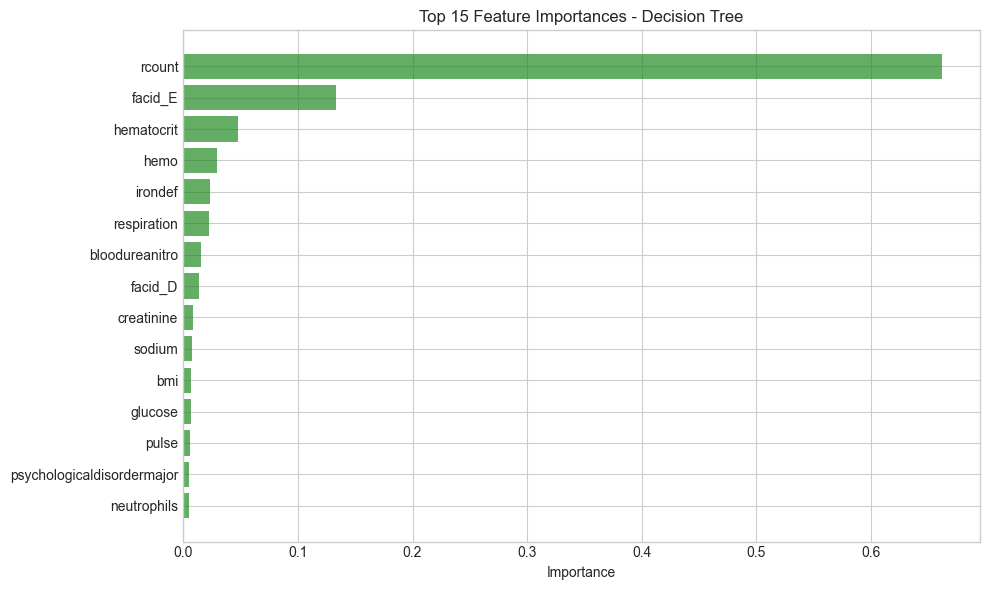

In [25]:
# Feature importance - Decision Tree
dt_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(dt_importance['Feature'][:15], dt_importance['Importance'][:15], color='forestgreen', alpha=0.7)
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - Decision Tree')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 7.7 Random Forest

In [26]:
# 7. RANDOM FOREST
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_results = evaluate_model(rf_model, X_train, X_test, y_train, y_test, "Random Forest")
all_results.append(rf_results)
print_model_results(rf_results)


📊 Random Forest

  TRAIN:
    MAE  : 0.4395 jours
    RMSE : 0.5713 jours
    R²   : 0.9416

  TEST:
    MAE  : 0.5297 jours
    RMSE : 0.7257 jours
    R²   : 0.9040

  ✅ Bonne généralisation (gap R²: 0.0376)


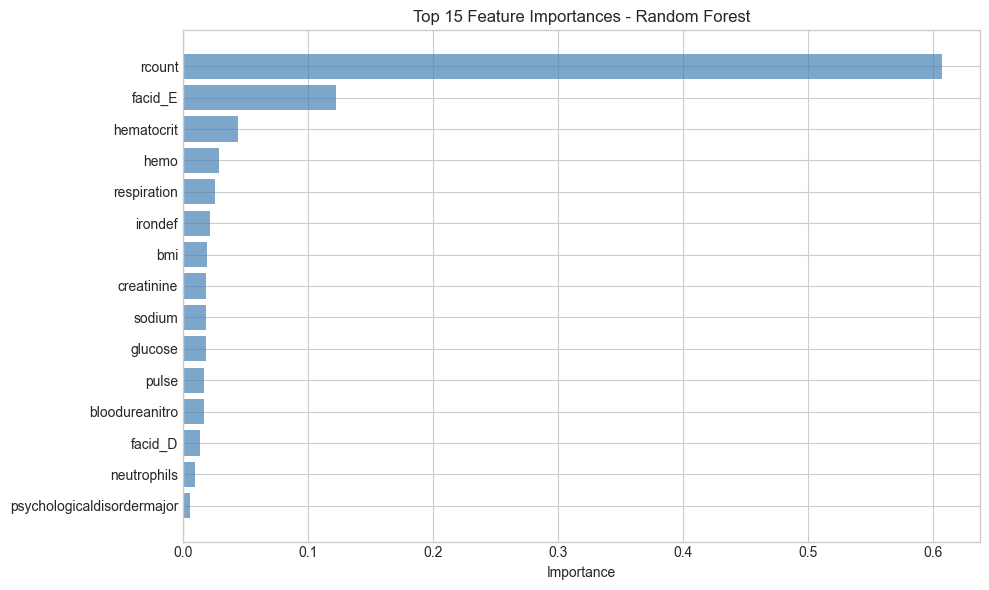

In [27]:
# Feature importance - Random Forest
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(rf_importance['Feature'][:15], rf_importance['Importance'][:15], color='steelblue', alpha=0.7)
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 7.8 Gradient Boosting

In [28]:
# 8. GRADIENT BOOSTING
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
gb_model.fit(X_train, y_train)

gb_results = evaluate_model(gb_model, X_train, X_test, y_train, y_test, "Gradient Boosting")
all_results.append(gb_results)
print_model_results(gb_results)


📊 Gradient Boosting

  TRAIN:
    MAE  : 0.3604 jours
    RMSE : 0.4654 jours
    R²   : 0.9613

  TEST:
    MAE  : 0.3706 jours
    RMSE : 0.4863 jours
    R²   : 0.9569

  ✅ Bonne généralisation (gap R²: 0.0044)


### 7.9 XGBoost

In [29]:
# 9. XGBOOST
xgb_model = None
if XGBOOST_AVAILABLE:
    xgb_model = XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
    xgb_model.fit(X_train, y_train)
    
    xgb_results = evaluate_model(xgb_model, X_train, X_test, y_train, y_test, "XGBoost")
    all_results.append(xgb_results)
    print_model_results(xgb_results)
else:
    print("⚠️ XGBoost non disponible - installer avec: !pip install xgboost")


📊 XGBoost

  TRAIN:
    MAE  : 0.3373 jours
    RMSE : 0.4326 jours
    R²   : 0.9665

  TEST:
    MAE  : 0.3593 jours
    RMSE : 0.4735 jours
    R²   : 0.9591

  ✅ Bonne généralisation (gap R²: 0.0074)


### 7.10 Support Vector Regression (SVR)

⚠️ **Note** : SVR est lent sur de grands datasets. On utilise un échantillon.

In [30]:
# 10. SVR (sur échantillon car lent)
# Sous-échantillonnage pour SVR
sample_size = 10000
np.random.seed(42)
sample_idx = np.random.choice(len(X_train_scaled), sample_size, replace=False)

X_train_sample = X_train_scaled[sample_idx]
y_train_sample = y_train.iloc[sample_idx]

svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_model.fit(X_train_sample, y_train_sample)

# Évaluation sur le test complet
svr_results = evaluate_model(svr_model, X_train_sample, X_test_scaled, y_train_sample, y_test, "SVR (échantillon)")
all_results.append(svr_results)
print_model_results(svr_results)
print(f"\n📌 SVR entraîné sur {sample_size:,} échantillons (au lieu de {len(X_train):,})")


📊 SVR (échantillon)

  TRAIN:
    MAE  : 0.5037 jours
    RMSE : 0.7660 jours
    R²   : 0.8952

  TEST:
    MAE  : 0.6057 jours
    RMSE : 0.8730 jours
    R²   : 0.8611

  ✅ Bonne généralisation (gap R²: 0.0340)

📌 SVR entraîné sur 10,000 échantillons (au lieu de 80,000)


---
## 8. Comparaison Finale des Modèles

In [31]:
# Tableau récapitulatif
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('Test_R2', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("📊 TABLEAU COMPARATIF DES MODÈLES (trié par R² Test)")
print("="*80)

# Formater pour l'affichage
display_df = results_df.copy()
for col in ['Train_MAE', 'Test_MAE', 'Train_RMSE', 'Test_RMSE']:
    display_df[col] = display_df[col].round(4)
for col in ['Train_R2', 'Test_R2']:
    display_df[col] = display_df[col].round(4)

print(display_df.to_string(index=False))


📊 TABLEAU COMPARATIF DES MODÈLES (trié par R² Test)
              Model  Train_MAE  Train_RMSE  Train_R2  Test_MAE  Test_RMSE  Test_R2
            XGBoost     0.3373      0.4326    0.9665    0.3593     0.4735   0.9591
  Gradient Boosting     0.3604      0.4654    0.9613    0.3706     0.4863   0.9569
      Random Forest     0.4395      0.5713    0.9416    0.5297     0.7257   0.9040
  SVR (échantillon)     0.5037      0.7660    0.8952    0.6057     0.8730   0.8611
      Decision Tree     0.6987      0.9082    0.8525    0.7406     0.9872   0.8224
      KNN Regressor     0.0000      0.0000    1.0000    0.7569     1.1243   0.7696
   Lasso Regression     0.8777      1.1562    0.7609    0.8667     1.1341   0.7656
         ElasticNet     0.8771      1.1559    0.7611    0.8660     1.1341   0.7656
   Ridge Regression     0.8770      1.1556    0.7612    0.8664     1.1348   0.7653
Régression Linéaire     0.8770      1.1556    0.7612    0.8664     1.1348   0.7653


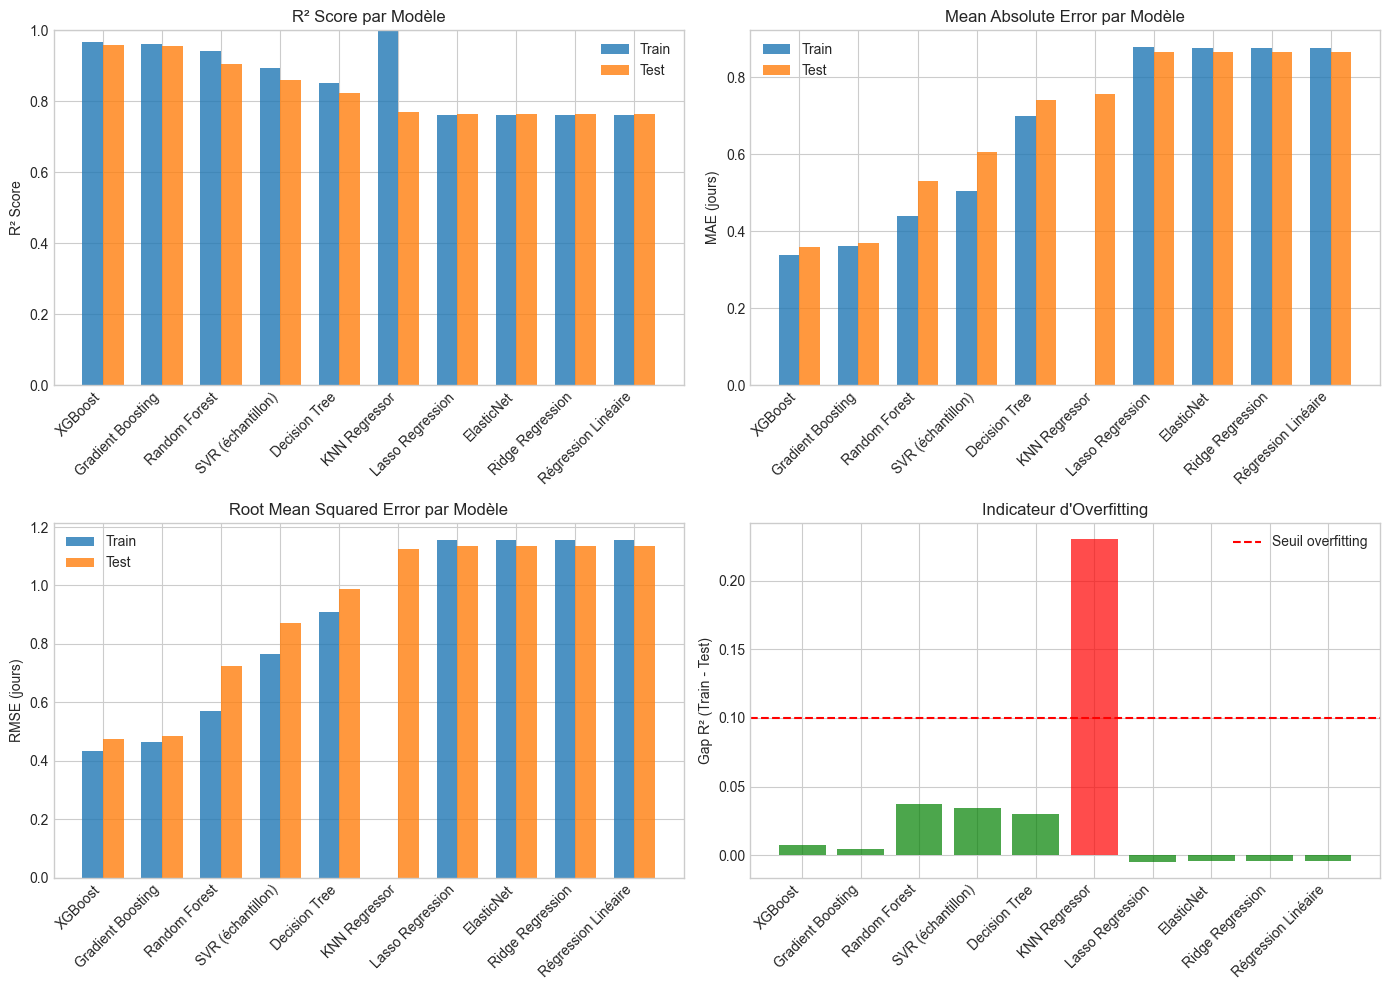

In [32]:
# Visualisation comparative
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = results_df['Model']
colors = plt.cm.viridis(np.linspace(0, 0.8, len(models)))

# R² Score
ax1 = axes[0, 0]
x = np.arange(len(models))
width = 0.35
ax1.bar(x - width/2, results_df['Train_R2'], width, label='Train', alpha=0.8)
ax1.bar(x + width/2, results_df['Test_R2'], width, label='Test', alpha=0.8)
ax1.set_ylabel('R² Score')
ax1.set_title('R² Score par Modèle')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.legend()
ax1.set_ylim(0, 1)

# MAE
ax2 = axes[0, 1]
ax2.bar(x - width/2, results_df['Train_MAE'], width, label='Train', alpha=0.8)
ax2.bar(x + width/2, results_df['Test_MAE'], width, label='Test', alpha=0.8)
ax2.set_ylabel('MAE (jours)')
ax2.set_title('Mean Absolute Error par Modèle')
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.legend()

# RMSE
ax3 = axes[1, 0]
ax3.bar(x - width/2, results_df['Train_RMSE'], width, label='Train', alpha=0.8)
ax3.bar(x + width/2, results_df['Test_RMSE'], width, label='Test', alpha=0.8)
ax3.set_ylabel('RMSE (jours)')
ax3.set_title('Root Mean Squared Error par Modèle')
ax3.set_xticks(x)
ax3.set_xticklabels(models, rotation=45, ha='right')
ax3.legend()

# Écart Train-Test (Overfitting indicator)
ax4 = axes[1, 1]
overfit_gap = results_df['Train_R2'] - results_df['Test_R2']
colors_overfit = ['red' if g > 0.1 else 'green' for g in overfit_gap]
ax4.bar(models, overfit_gap, color=colors_overfit, alpha=0.7)
ax4.axhline(y=0.1, color='red', linestyle='--', label='Seuil overfitting')
ax4.set_ylabel('Gap R² (Train - Test)')
ax4.set_title('Indicateur d\'Overfitting')
ax4.set_xticklabels(models, rotation=45, ha='right')
ax4.legend()

plt.tight_layout()
plt.show()

In [33]:
# Meilleur modèle
best_model = results_df.iloc[0]
print("\n" + "="*60)
print("🏆 MEILLEUR MODÈLE")
print("="*60)
print(f"\n  Modèle : {best_model['Model']}")
print(f"  R² Test : {best_model['Test_R2']:.4f}")
print(f"  MAE Test : {best_model['Test_MAE']:.4f} jours")
print(f"  RMSE Test : {best_model['Test_RMSE']:.4f} jours")


🏆 MEILLEUR MODÈLE

  Modèle : XGBoost
  R² Test : 0.9591
  MAE Test : 0.3593 jours
  RMSE Test : 0.4735 jours


---
## 9. Analyse des Prédictions du Meilleur Modèle

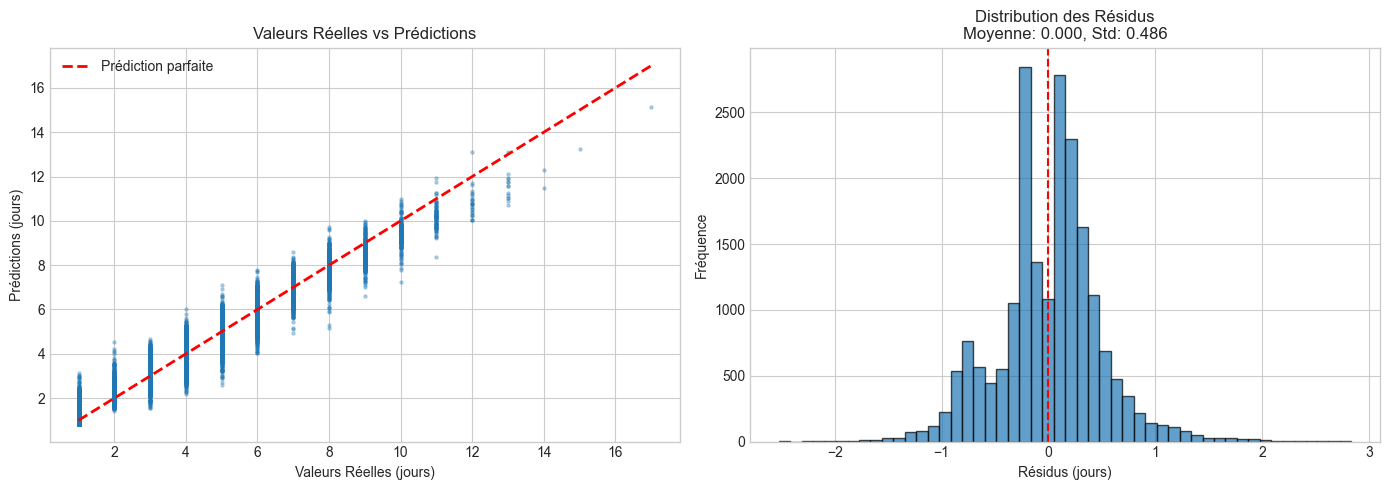

In [34]:
# Utilisons le modèle Gradient Boosting ou Random Forest pour l'analyse
best_trained_model = gb_model  # ou rf_model
y_pred = best_trained_model.predict(X_test)

# Scatter plot : Valeurs réelles vs Prédictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(y_test, y_pred, alpha=0.3, s=5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs Réelles (jours)')
axes[0].set_ylabel('Prédictions (jours)')
axes[0].set_title('Valeurs Réelles vs Prédictions')
axes[0].legend()

# Distribution des résidus
residuals = y_test - y_pred
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Résidus (jours)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title(f'Distribution des Résidus\nMoyenne: {residuals.mean():.3f}, Std: {residuals.std():.3f}')

plt.tight_layout()
plt.show()

---
## 10. Conclusions et Recommandations

### Résumé des observations :

1. **Régression Linéaire** : Bonne baseline, interprétable, mais performances limitées sur ce dataset non-linéaire.

2. **Ridge/Lasso/ElasticNet** : Apportent peu d'amélioration car il y a peu de multicolinéarité problématique.

3. **KNN** : Sensible au bruit et à la dimensionnalité.

4. **Decision Tree** : Risque d'overfitting si non contrôlé.

5. **Random Forest / Gradient Boosting / XGBoost** : Meilleurs performances, capturent les relations non-linéaires.

### Recommandations :

- **Pour l'interprétabilité** : Régression Linéaire ou Decision Tree (peu profond)
- **Pour la performance** : Gradient Boosting ou XGBoost avec tuning des hyperparamètres
- **Features les plus importantes** : `rcount` (nombre de réadmissions), mesures biologiques, diagnostics secondaires

In [35]:
# Export des résultats
results_df.to_csv('model_comparison_results.csv', index=False)
print("✅ Résultats exportés dans 'model_comparison_results.csv'")

✅ Résultats exportés dans 'model_comparison_results.csv'


---
## 11. 💾 Sauvegarde du Modèle XGBoost pour l'API

In [36]:
import os

os.makedirs("models", exist_ok=True)

# Sauvegarde au format JSON natif XGBoost
xgb_model.save_model("models/xgboost_los_model.json")

file_size = os.path.getsize("models/xgboost_los_model.json") / 1024
print(f"✅ Modèle sauvegardé : models/xgboost_los_model.json")
print(f"   Taille            : {file_size:.1f} Ko")
print(f"   Features utilisées: {list(X.columns)}")


✅ Modèle sauvegardé : models/xgboost_los_model.json
   Taille            : 672.3 Ko
   Features utilisées: ['rcount', 'gender', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9', 'facid_B', 'facid_C', 'facid_D', 'facid_E']


In [37]:
from xgboost import XGBRegressor

# Rechargement depuis le fichier JSON
model_loaded = XGBRegressor()
model_loaded.load_model("models/xgboost_los_model.json")

# Test sur 5 patients du jeu de test
sample = X_test.iloc[:5]
predictions = model_loaded.predict(sample)
real_values  = y_test.iloc[:5].values

print("Vérification sur 5 patients :")
print(f"{'Patient':<10} {'Prédit':>12} {'Réel':>8} {'Écart':>10}")
print("-" * 44)
for i, (pred, real) in enumerate(zip(predictions, real_values)):
    print(f"{i+1:<10} {pred:>10.2f}j {real:>6.0f}j {abs(pred-real):>8.2f}j")

print(f"\n✅ Modèle rechargé et fonctionnel — prêt pour l'API !")


Vérification sur 5 patients :
Patient          Prédit     Réel      Écart
--------------------------------------------
1                3.73j      4j     0.27j
2                0.83j      1j     0.17j
3                2.51j      2j     0.51j
4                1.12j      1j     0.12j
5                5.13j      5j     0.13j

✅ Modèle rechargé et fonctionnel — prêt pour l'API !


### 🚀 Utilisation dans l'API

In [38]:
# ──────────────────────────────────────────────────────
# Snippet à copier dans ton API (FastAPI / Flask)
# ──────────────────────────────────────────────────────

snippet = '''
from xgboost import XGBRegressor
import pandas as pd

# Charger une seule fois au démarrage de l'API
model = XGBRegressor()
model.load_model("models/xgboost_los_model.json")

# Colonnes attendues (dans le même ordre qu'à l'entraînement)
FEATURE_COLUMNS = ''' + str(list(X.columns)) + '''

def predict_length_of_stay(patient_data: dict) -> float:
    df_input = pd.DataFrame([patient_data])[FEATURE_COLUMNS]
    prediction = model.predict(df_input)
    return round(float(prediction[0]), 2)
'''

print(snippet)



from xgboost import XGBRegressor
import pandas as pd

# Charger une seule fois au démarrage de l'API
model = XGBRegressor()
model.load_model("models/xgboost_los_model.json")

# Colonnes attendues (dans le même ordre qu'à l'entraînement)
FEATURE_COLUMNS = ['rcount', 'gender', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9', 'facid_B', 'facid_C', 'facid_D', 'facid_E']

def predict_length_of_stay(patient_data: dict) -> float:
    df_input = pd.DataFrame([patient_data])[FEATURE_COLUMNS]
    prediction = model.predict(df_input)
    return round(float(prediction[0]), 2)

